In [ ]:
import numpy as np
import random
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import gc
import sys
import os
import copy
import warnings
import unittest.mock as mock
warnings.filterwarnings('ignore')

class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

with HiddenPrints():
    with mock.patch('matplotlib.pyplot.subplots',
                    return_value=(mock.MagicMock(), mock.MagicMock())):
        from env_R11_v2 import motorEnv

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


In [6]:
with HiddenPrints():
    with mock.patch('matplotlib.pyplot.subplots',
                    return_value=(mock.MagicMock(), mock.MagicMock())):
        env = motorEnv()

env.ax = mock.MagicMock()
n_states  = env.num_states
n_actions = env.action_space.n

print(f'Numero de estados  : {n_states}')
print(f'Numero de acciones : {n_actions}')
print(f'RAM Q-Table        : {n_states * n_actions * 8 / 1024 / 1024:.1f} MB')

Numero de estados  : 179600
Numero de acciones : 4
RAM Q-Table        : 5.5 MB


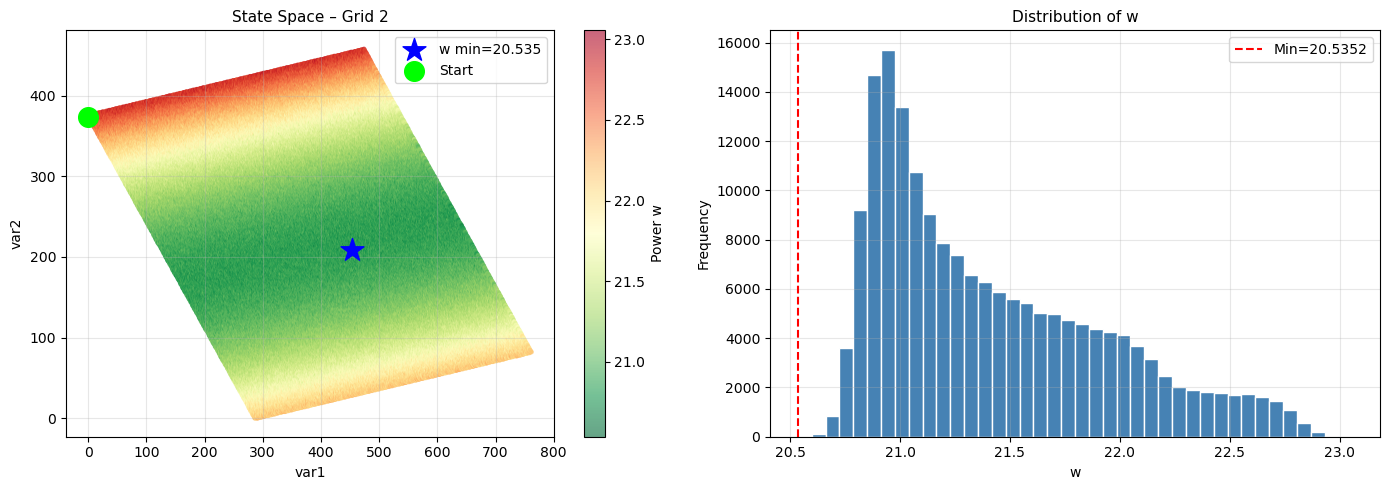

In [7]:
%matplotlib inline
df = env.rot.copy()
idx_min_viz = df['w'].idxmin()
w_min_viz   = df['w'].min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(df['var1'], df['var2'], c=df['w'], cmap='RdYlGn_r', s=5, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='Power w')
axes[0].scatter(df.loc[idx_min_viz,'var1'], df.loc[idx_min_viz,'var2'],
                c='blue', s=300, marker='*', zorder=6, label=f'w min={w_min_viz:.3f}')
axes[0].scatter(df.iloc[0]['var1'], df.iloc[0]['var2'],
                c='lime', s=200, marker='o', zorder=6, label='Start')
axes[0].set_title('State Space – Grid 2', fontsize=11)
axes[0].set_xlabel('var1'); axes[0].set_ylabel('var2')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(df['w'], bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(w_min_viz, color='red', linestyle='--', label=f'Min={w_min_viz:.4f}')
axes[1].set_title('Distribution of w', fontsize=11)
axes[1].set_xlabel('w'); axes[1].set_ylabel('Frequency')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
def test_greedy(env, q_table, max_steps=5000, seed=545):
    """Ejecuta un test greedy (epsilon=0) y devuelve pasos y si alcanzo objetivo."""
    np.random.seed(seed)
    random.seed(seed)
    env.action_space.seed(seed)

    with HiddenPrints():
        state = env.reset()
    env.ax = mock.MagicMock()

    estados_visitados = set([state])
    pasos             = 0
    alcanzo           = False
    path_w            = [env.rot.iloc[state]['w']]
    path_var1         = [env.rot.iloc[state]['var1']]
    path_var2         = [env.rot.iloc[state]['var2']]

    for _ in range(max_steps):
        action = np.argmax(q_table[state])
        with HiddenPrints():
            next_state, reward, done, _ = env.step(action)
        env.ax = mock.MagicMock()

        path_w.append(env.rot.iloc[next_state]['w'])
        path_var1.append(env.rot.iloc[next_state]['var1'])
        path_var2.append(env.rot.iloc[next_state]['var2'])
        pasos += 1

        if done:
            alcanzo = True
            break
        if next_state in estados_visitados:
            break

        estados_visitados.add(next_state)
        state = next_state

    return pasos, alcanzo, path_w, path_var1, path_var2

print('Funcion test_greedy definida.')

Funcion test_greedy definida.


In [9]:
# ── Parámetros (idénticos a v2) ───────────────────────────────────────────
SEED          = 545
MAX_STEPS     = 5000
MAX_EPISODES  = 8000
CHECKPOINT_C  = 1000   # test greedy cada N episodios

ALPHA         = 0.8
GAMMA         = 0.995
EPSILON       = 1.0
EPSILON_DECAY = 0.995
MIN_EPSILON   = 0.05
COSTE_PASO    = 1.0
VISIT_FACTOR  = 3.0

np.random.seed(SEED)
random.seed(SEED)
env.action_space.seed(SEED)

q_table            = np.zeros([n_states, n_actions])
best_w_overall     = float('inf')
best_steps_goal    = float('inf')
rewards_hist       = []
steps_hist         = []
done_hist          = []
epsilon_hist       = []
checkpoints        = []   # (episodio, pasos_test, alcanzo)
best_q_table       = None # mejor Q-Table encontrada por test
best_test_pasos    = float('inf')

print('=' * 68)
print(f'ENTRENAMIENTO v2 extendido ({MAX_EPISODES} ep) con checkpoints cada {CHECKPOINT_C} ep')
print('=' * 68)
print(f'  alpha={ALPHA} | gamma={GAMMA} | eps: {EPSILON}→{MIN_EPSILON} (decay={EPSILON_DECAY})')
print(f'  coste_paso={COSTE_PASO} | visit_factor={VISIT_FACTOR}')
print('=' * 68)
plt.ioff()

pbar = tqdm(range(MAX_EPISODES), desc='Entrenando')

for episode in pbar:

    with HiddenPrints():
        state = env.reset()
    env.ax = mock.MagicMock()

    visit_counts    = np.zeros(n_states)
    prev_w          = env.rot.iloc[state]['w']
    done            = False
    episode_history = []
    total_reward    = 0
    steps           = 0

    for step in range(MAX_STEPS):

        if random.uniform(0, 1) < EPSILON:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        with HiddenPrints():
            next_state, env_reward, done, _ = env.step(action)
        env.ax = mock.MagicMock()

        current_w = env.rot.iloc[next_state]['w']
        visit_counts[next_state] += 1

        if current_w < best_w_overall:
            best_w_overall = current_w

        custom_reward  = (prev_w - current_w) * 100
        custom_reward -= COSTE_PASO
        custom_reward -= visit_counts[next_state] * VISIT_FACTOR
        if next_state == state:
            custom_reward -= 50
        if done:
            custom_reward += 10000
            if steps + 1 < best_steps_goal:
                best_steps_goal = steps + 1

        old_value = q_table[state, action]
        next_max  = np.max(q_table[next_state])
        q_table[state, action] = ((1 - ALPHA) * old_value
                                  + ALPHA * (custom_reward + GAMMA * next_max))

        episode_history.append((state, action, custom_reward, next_state))
        state         = next_state
        prev_w        = current_w
        total_reward += custom_reward
        steps        += 1

        if done:
            break

    for s, a, r, nxt_s in reversed(episode_history):
        old_value = q_table[s, a]
        next_max  = np.max(q_table[nxt_s])
        q_table[s, a] = ((1 - ALPHA) * old_value
                         + ALPHA * (r + GAMMA * next_max))

    EPSILON = max(MIN_EPSILON, EPSILON * EPSILON_DECAY)

    rewards_hist.append(total_reward)
    steps_hist.append(steps)
    done_hist.append(done)
    epsilon_hist.append(EPSILON)

    # ── Checkpoint: test greedy cada CHECKPOINT_C episodios ───────────────
    if (episode + 1) % CHECKPOINT_C == 0:
        t_pasos, t_alcanzo, _, _, _ = test_greedy(env, q_table, MAX_STEPS, SEED)
        checkpoints.append((episode + 1, t_pasos, t_alcanzo))

        # Guardar la mejor Q-Table vista hasta ahora
        if t_alcanzo and t_pasos < best_test_pasos:
            best_test_pasos = t_pasos
            best_q_table    = q_table.copy()

        tqdm.write(f'  [Checkpoint ep {episode+1:5d}] '
                   f'test={t_pasos} pasos | '
                   f'alcanzo={t_alcanzo} | '
                   f'min_train={best_steps_goal} | '
                   f'mejor_test={best_test_pasos}')

        if (episode + 1) % 50 == 0:
            gc.collect()

    pbar.set_postfix({
        'Mejor_w'   : f'{best_w_overall:.4f}',
        'Min_pasos' : best_steps_goal if best_steps_goal < float('inf') else '-',
        'Mejor_test': best_test_pasos if best_test_pasos < float('inf') else '-',
        'Eps'       : f'{EPSILON:.3f}',
        'Exitos'    : sum(done_hist)
    })

print(f'\nEntrenamiento finalizado.')
print(f'  Episodios exitosos: {sum(done_hist)}/{MAX_EPISODES}')
print(f'  Min pasos (entrenamiento): {best_steps_goal}')
print(f'  Mejor test greedy         : {best_test_pasos} pasos')
print(f'\nResumen de checkpoints:')
for ep, tp, ta in checkpoints:
    print(f'  Ep {ep:5d}: test={tp} pasos | alcanzo={ta}')

ENTRENAMIENTO v2 extendido (8000 ep) con checkpoints cada 1000 ep
  alpha=0.8 | gamma=0.995 | eps: 1.0→0.05 (decay=0.995)
  coste_paso=1.0 | visit_factor=3.0


Entrenando:  12%|█▎        | 1000/8000 [2:10:08<15:07:15,  7.78s/it, Mejor_w=20.5848, Min_pasos=-, Mejor_test=-, Eps=0.050, Exitos=0]

  [Checkpoint ep  1000] test=30 pasos | alcanzo=False | min_train=inf | mejor_test=inf


Entrenando:  25%|██▌       | 2000/8000 [4:19:03<11:38:31,  6.99s/it, Mejor_w=20.5352, Min_pasos=2382, Mejor_test=-, Eps=0.050, Exitos=115]

  [Checkpoint ep  2000] test=19 pasos | alcanzo=False | min_train=2382 | mejor_test=inf


...

  [Checkpoint ep  7000] test=666 pasos | alcanzo=True | min_train=689 | mejor_test=666


Entrenando: 100%|█████████▉| 7999/8000 [7:58:24<00:01,  1.62s/it, Mejor_w=20.5352, Min_pasos=679, Mejor_test=664, Eps=0.050, Exitos=5802]

  [Checkpoint ep  8000] test=664 pasos | alcanzo=True | min_train=679 | mejor_test=664


Entrenando: 100%|██████████| 8000/8000 [7:58:24<00:00,  3.59s/it, Mejor_w=20.5352, Min_pasos=679, Mejor_test=664, Eps=0.050, Exitos=5802]


Entrenamiento finalizado.
  Episodios exitosos: 5802/8000
  Min pasos (entrenamiento): 679
  Mejor test greedy         : 664 pasos

Resumen de checkpoints:
  Ep  1000: test=30 pasos | alcanzo=False
  Ep  2000: test=19 pasos | alcanzo=False
  Ep  3000: test=31 pasos | alcanzo=False
  Ep  4000: test=690 pasos | alcanzo=True
  Ep  5000: test=682 pasos | alcanzo=True
  Ep  6000: test=668 pasos | alcanzo=True
  Ep  7000: test=666 pasos | alcanzo=True
  Ep  8000: test=664 pasos | alcanzo=True


In [17]:
# Usar la mejor Q-Table guardada en checkpoints
q_usar = best_q_table if best_q_table is not None else q_table
print(f'Usando Q-Table del checkpoint con {best_test_pasos} pasos.')

with mock.patch('matplotlib.pyplot.subplots', return_value=(mock.MagicMock(), mock.MagicMock())):
    pasos_totales, alcanzo, path_w, path_var1, path_var2 = test_greedy(
        env, q_usar, MAX_STEPS, SEED
    )

print(f'\nResultados del test final:')
print(f'  Pasos realizados       : {pasos_totales}')
print(f'  Potencia inicial (w)   : {path_w[0]:.4f}')
print(f'  Potencia final   (w)   : {path_w[-1]:.4f}')
print(f'  w minimo del CSV       : {env.rot["w"].min():.4f}')
print(f'  Objetivo alcanzado     : {"SI" if alcanzo else "NO"}')

Usando Q-Table del checkpoint con 664 pasos.

Resultados del test final:
  Pasos realizados       : 664
  Potencia inicial (w)   : 22.6062
  Potencia final   (w)   : 20.5352
  w minimo del CSV       : 20.5352
  Objetivo alcanzado     : SI


In [ ]:
ruta_df = pd.DataFrame({
    'paso' : list(range(len(path_var1))),
    'var1' : path_var1,
    'var2' : path_var2,
    'w'    : path_w
})

nombre_csv = f'Datos/Transformados/RL/ruta_optima_malla2_{pasos_totales}_pasos.csv'
ruta_df.to_csv(nombre_csv, index=False)

print(f'CSV guardado como: {nombre_csv}')
print(f'Filas totales    : {len(ruta_df)} (1 estado inicial + {pasos_totales} pasos)')
print(f'Potencia inicial : {ruta_df["w"].iloc[0]:.4f} kW')
print(f'Potencia final   : {ruta_df["w"].iloc[-1]:.4f} kW')
print(f'Minimo de w      : {ruta_df["w"].min():.4f} kW')
print()
print('Primeras 5 filas:')
print(ruta_df.head().to_string(index=False))
print()
print('Ultimas 5 filas:')
print(ruta_df.tail().to_string(index=False))

CSV guardado como: ruta_optima_malla2_664_pasos.csv
Filas totales    : 665 (1 estado inicial + 664 pasos)
Potencia inicial : 22.6062 kW
Potencia final   : 20.5352 kW
Minimo de w      : 20.5352 kW

Primeras 5 filas:
 paso  var1  var2         w
    0   0.0 374.0 22.606224
    1   0.0 375.0 22.766978
    2   1.0 375.0 22.737465
    3   2.0 375.0 22.752046
    4   3.0 375.0 22.820955

Ultimas 5 filas:
 paso  var1  var2         w
  660 451.0 207.0 20.890178
  661 452.0 207.0 20.885779
  662 453.0 207.0 20.913492
  663 454.0 207.0 20.783496
  664 454.0 208.0 20.535195


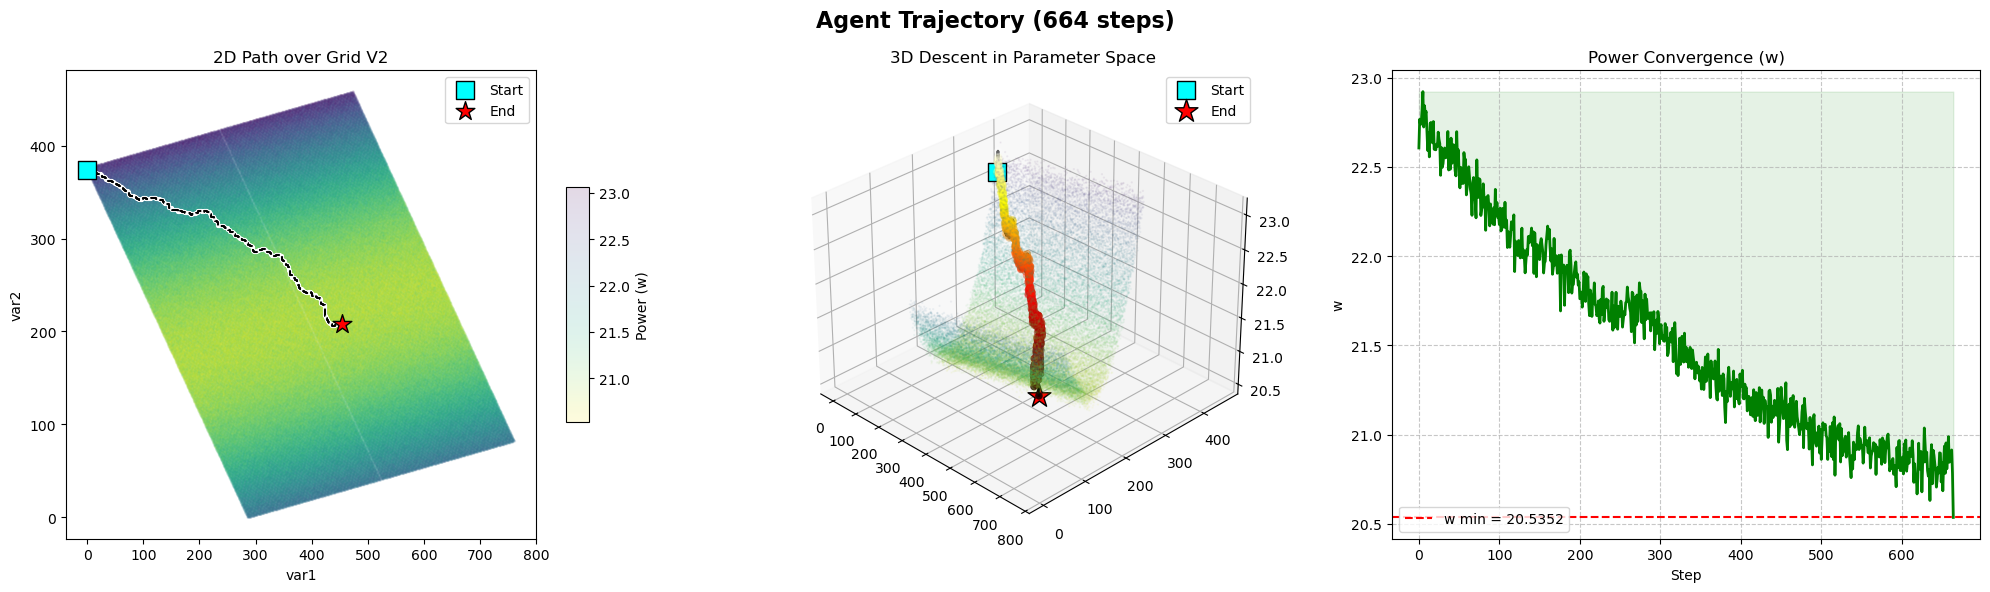

In [13]:
%matplotlib inline
all_var1 = env.rot['var1'].values
all_var2 = env.rot['var2'].values
all_w    = env.rot['w'].values

plt.close('all')
fig = plt.figure(figsize=(20, 6))
fig.suptitle(f'Agent Trajectory ({pasos_totales} steps)',
             fontsize=16, fontweight='bold')

ax1 = fig.add_subplot(1, 3, 1)
malla_2d = ax1.scatter(all_var1, all_var2, c=all_w, cmap='viridis_r', s=1, alpha=0.15)
ax1.plot(path_var1, path_var2, color='white', linewidth=3, zorder=4)
ax1.plot(path_var1, path_var2, color='black', linestyle='--', linewidth=1.5, zorder=5)
ax1.scatter(path_var1[0], path_var2[0], color='cyan', edgecolors='black',
            s=150, marker='s', label='Start', zorder=6)
ax1.scatter(path_var1[-1], path_var2[-1], color='red', edgecolors='black',
            s=200, marker='*', label='End', zorder=6)
ax1.set_title('2D Path over Grid V2')
ax1.set_xlabel('var1'); ax1.set_ylabel('var2'); ax1.legend()
fig.colorbar(malla_2d, ax=ax1, shrink=0.5, aspect=10, label='Power (w)')

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.scatter(all_var1[::5], all_var2[::5], all_w[::5],
            c=all_w[::5], cmap='viridis_r', s=0.5, alpha=0.05)
ax2.plot(path_var1, path_var2, path_w, color='black', linewidth=2, zorder=4)
ax2.scatter(path_var1, path_var2, path_w, c=path_w, cmap='hot',
            marker='o', s=30, edgecolors='none', zorder=5)
ax2.scatter(path_var1[0], path_var2[0], path_w[0], color='cyan',
            s=150, marker='s', edgecolors='black', label='Start')
ax2.scatter(path_var1[-1], path_var2[-1], path_w[-1], color='red',
            s=300, marker='*', edgecolors='black', label='End')
ax2.set_title('3D Descent in Parameter Space')
ax2.view_init(elev=30, azim=-45); ax2.legend()

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(path_w, color='green', linewidth=2)
ax3.fill_between(range(len(path_w)), path_w, max(path_w), color='green', alpha=0.1)
ax3.axhline(env.rot['w'].min(), color='red', linestyle='--',
            label=f'w min = {env.rot["w"].min():.4f}')
ax3.set_title('Power Convergence (w)')
ax3.set_xlabel('Step'); ax3.set_ylabel('w')
ax3.legend(); ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
print('\n' + '='*68)
print('RESUMEN FINAL – MALLA 2 (Datos_v2)')
print('='*68)
print(f'  Episodios totales      : {MAX_EPISODES}')
print(f'  alpha={ALPHA} | gamma={GAMMA} | eps: {1.0}→{MIN_EPSILON} (decay={EPSILON_DECAY})')
print(f'  coste_paso={COSTE_PASO} | visit_factor={VISIT_FACTOR}')
print(f'  Episodios exitosos     : {sum(done_hist)}/{MAX_EPISODES}')
print(f'  Min pasos entrenamiento: {best_steps_goal}')
print(f'  Mejor test en checkpoints: {best_test_pasos} pasos')
print(f'  Test final             : {pasos_totales} pasos')
print(f'  w final                : {path_w[-1]:.4f}')
print(f'  Objetivo alcanzado     : {"SI" if alcanzo else "NO"}')
print('\n  Detalle checkpoints:')
for ep, tp, ta in checkpoints:
    print(f'    Ep {ep:5d}: {tp} pasos | OK={ta}')
print('='*68)


RESUMEN FINAL – MALLA 2 (Datos_v2)
  Episodios totales      : 8000
  alpha=0.8 | gamma=0.995 | eps: 1.0→0.05 (decay=0.995)
  coste_paso=1.0 | visit_factor=3.0
  Episodios exitosos     : 5802/8000
  Min pasos entrenamiento: 679
  Mejor test en checkpoints: 664 pasos
  Test final             : 664 pasos
  w final                : 20.5352
  Objetivo alcanzado     : SI

  Detalle checkpoints:
    Ep  1000: 30 pasos | OK=False
    Ep  2000: 19 pasos | OK=False
    Ep  3000: 31 pasos | OK=False
    Ep  4000: 690 pasos | OK=True
    Ep  5000: 682 pasos | OK=True
    Ep  6000: 668 pasos | OK=True
    Ep  7000: 666 pasos | OK=True
    Ep  8000: 664 pasos | OK=True
